# E-Commerce Customer Retention & Cohort Analysis

Complete analytical walkthrough in one notebook. Saved outputs can be read without running code. To execute all cells, first rebuild the project with `python src/run_pipeline.py` as described in the README.

## Contents

1. [Raw data audit and cleaning](#data-audit)
2. [Cohort validation and visualization](#cohorts)
3. [RFM, customer value and business differences](#customer-value)

Historical UK retail data; all money is GBP. This is observational analysis, not a campaign impact evaluation.

<a id="data-audit"></a>

# 01 - Raw Data Audit and Cleaning

Steps 5 and 6 completed. Run `python src/audit_data.py` then `python src/clean_data.py`. This notebook reviews their outputs. The first section retains the historical Step 5 audit; the following cleaning section uses the explicit version 1.1 price rule. Source data describe historical UK retail in GBP.

In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import duckdb
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src/metric_spec.json").exists():
    ROOT = ROOT.parent
assert (ROOT / "src/metric_spec.json").exists(), "Open from the project root or notebooks directory."
summary_path = ROOT / "reports/data_quality_summary.json"
assert summary_path.exists(), "Run python src/audit_data.py first."
summary = json.loads(summary_path.read_text(encoding="utf-8"))
manifest = json.loads((ROOT / "data/raw/source_manifest.json").read_text(encoding="utf-8"))
assert hashlib.sha256((ROOT / manifest["local_workbook"]).read_bytes()).hexdigest() == summary["source_sha256"] == manifest["workbook_sha256"]
with duckdb.connect(str(ROOT / summary["database"]), read_only=True) as con:
    actual_count = con.execute("SELECT count(*) FROM raw_order_lines").fetchone()[0]
assert actual_count == summary["source_rows"] == manifest["raw_row_count"]
results = summary["results"]
print(f"Verified original workbook and {actual_count:,} preserved source rows.")
display(pd.DataFrame(results["source_inventory"]))

Verified original workbook and 1,067,371 preserved source rows.


,source_sheet,rows,first_excel_row,last_excel_row,distinct_row_numbers,first_timestamp,last_timestamp,workbook_hashes
0,Year 2009-2010,525461,2,525462,525461,2009-12-01T07:45:00,2010-12-09T20:01:00,1
1,Year 2010-2011,541910,2,541911,541910,2010-12-01T08:26:00,2011-12-09T12:50:00,1


## Missing fields and identity
Counts are raw item rows, not orders. Unknown customers cannot be treated as one person.

In [2]:
missing = pd.DataFrame(results["missing_fields"])
missing["percent_raw_rows"] = (100 * missing["missing_rows"] / actual_count).round(2)
display(missing)
display(pd.DataFrame(results["quality_flags"]).T.rename(columns={0: "raw_value"}))
display(pd.DataFrame(results["header_summary"]))

,field,missing_rows,percent_raw_rows
0,Invoice,0,0.00
1,StockCode,0,0.00
2,Description,4382,0.41
3,Quantity,0,0.00
4,InvoiceDate,0,0.00
5,Price,0,0.00
6,Customer ID,243007,22.77
7,Country,0,0.00


,raw_value
raw_rows,1067371
invalid_or_nonintegral_quantity_rows,0
invalid_or_excess_precision_price_rows,112879
invalid_date_rows,0
malformed_customer_rows,0
cancellation_prefix_rows,19494
other_invoice_format_rows,6
negative_quantity_rows,22950
zero_quantity_rows,0
negative_price_rows,5


,invoice_versions,multiple_timestamp_versions,multiple_customer_versions,multiple_country_versions,unidentified_versions,versions_with_inheritable_missing_ids
0,54716,84,0,0,8939,0


## Overlap and duplicates

Compare invoice multisets first; then within-version identical lines. These are proposed dispositions, not deletions. Monetary amounts use the provisional price scenario below and include unresolved non-merchandise rows.

In [3]:
display(pd.DataFrame(results["overlap_summary"]))
dispositions = pd.DataFrame(results["proposed_dispositions"])
assert dispositions["rows"].sum() == actual_count
display(dispositions)
display(pd.DataFrame(results["retained_review_exposure"]).T)
headers = pd.read_csv(ROOT / results["header_issues"]["file"], dtype={"invoice_id": "string"})
assert len(headers) == results["header_issues"]["rows"]
display(headers.head(10))

,overlap_status,invoices,rows_both_versions,candidate_positive_gbp_both_versions
0,identical,1088,45046,877705.300000


,proposed_disposition,rows,candidate_positive_gbp_all_dates,candidate_positive_gbp_main_period
0,exclude_older_overlap_copy,22523,438852.650000,438852.650000
1,exclude_within_version_duplicate,11812,57481.470000,56479.120000
2,retain_for_step_6_review,1033036,20465198.388000,19827390.058000


,0
rows_after_proposed_overlap_and_duplicate_handling,1007789
rows_in_header_conflicts,5721
header_conflict_candidate_gbp,98126.330000
candidate_positive_gbp,19827390.058000
unidentified_candidate_gbp,2969794.230000
rows_in_unidentified_invoices,227287


,source_sheet,invoice_id,payload_hash,source_rows,distinct_timestamps,invalid_date_rows,distinct_known_customers,missing_or_invalid_customer_rows,invalid_customer_rows,distinct_known_countries,candidate_positive_gbp
0,Year 2009-2010,492807,6773ec191ea46e591738aa13aad750c579e960e4605276...,30,2,0,1,0,0,1,342.82
1,Year 2009-2010,494166,85a718fdacbd4cabbc805ba66dfc13a0e105e74405a445...,240,2,0,0,240,0,1,1923.20
2,Year 2009-2010,499967,4f6c34808a11dd4d2bf4767b28cf94ae1abe8cd9f27671...,31,2,0,1,0,0,1,1311.45
3,Year 2009-2010,500353,287cd2023781c6b6902481076e87bcafffaaa8dcd58d42...,110,2,0,1,0,0,1,1966.84
4,Year 2009-2010,500827,2d3898633d58df6c1b553deafe1863d1a9dc61130d4452...,213,2,0,0,213,0,1,2163.04
5,Year 2009-2010,501618,b95295a0ebd5defd48003372d43e7589af69ed3f0d0dad...,19,2,0,1,0,0,1,296.42
6,Year 2009-2010,501871,31504a828332084bd2a4d040bc4491d508314530985f81...,15,2,0,1,0,0,1,658.00
7,Year 2009-2010,503609,b319cdf05110c3809363d2f9a5149fa9a943f522a45342...,10,2,0,1,0,0,1,819.42
8,Year 2009-2010,505791,1a408be333df40d87ed37de98505eac8fb39b747012374...,51,2,0,1,0,0,1,238.61
9,Year 2009-2010,509851,58b4ae9f083fb83317f1a317c6fbcaac545306fae24c7d...,69,2,0,1,0,0,1,1389.26


## Price precision and status proxies

112,879 raw prices fail the strict six-decimal contract. Their deviations are consistent with Excel serialization noise. Candidate amounts explicitly round to six decimals only if deviation is at most 1e-9 GBP; this is an audit scenario and requires a documented Step 6 contract revision before cleaning. C prefixes and quantity/price signs are proxies; no native completed-order status exists.

In [4]:
display(pd.DataFrame(results["price_precision_review"]))
print(summary["money_encoding"])
display(pd.DataFrame(results["amount_distribution"]).T)
outliers = pd.read_csv(ROOT / results["outlier_lines"]["file"], dtype={"invoice_id": "string", "customer_id": "string"})
display(outliers.head(12))

,price_precision_status,rows,maximum_absolute_review_delta_gbp,example_raw_price
0,exact_within_six_decimals,954492,0.000000000000000000,-11062.06
1,representation_noise_candidate,112879,0.000000000003000000,-38925.870000000003


Decimal strings in JSON; GBP. Candidate exposures use an explicit audit scenario: round to six decimals only where absolute raw-price deviation is <= 1e-9 GBP. Strict precision failures remain flagged; this is not an approved cleaning rule or final revenue.


,0
minimum_quantity,-80995
maximum_quantity,80995
minimum_unit_price_gbp,-53594.360000
maximum_unit_price_gbp,38970.000000
positive_quantity_p99,108.0
positive_price_p99,18.220000
largest_raw_positive_line_gbp,168469.600000


,source_sheet,source_row_number,invoice_id,stock_code,description,quantity,raw_price,unit_price_gbp,review_unit_price_gbp,invoice_timestamp,customer_id,candidate_positive_gbp
0,Year 2010-2011,540423,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,2.08,2.08,2011-12-09T09:15:00,16446,168469.60
1,Year 2010-2011,540424,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,2.08,2.08,2011-12-09T09:27:00,16446,0.00
2,Year 2010-2011,61621,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,1.04,1.04,2011-01-18T10:01:00,12346,77183.60
3,Year 2010-2011,61626,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,1.04,1.04,2011-01-18T10:17:00,12346,0.00
4,Year 2009-2010,179405,A506401,B,Adjust bad debt,1,-53594.36,-53594.36,-53594.36,2010-04-29T13:36:00,<NA>,0.00
5,Year 2009-2010,276276,A516228,B,Adjust bad debt,1,-44031.79,-44031.79,-44031.79,2010-07-19T11:24:00,<NA>,0.00
6,Year 2010-2011,222673,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,649.50,649.50,2011-06-10T15:28:00,15098,38970.00
7,Year 2010-2011,222683,C556445,M,Manual,-1,38970.00,38970.00,38970.00,2011-06-10T15:31:00,15098,0.00
8,Year 2009-2010,403474,A528059,B,Adjust bad debt,1,-38925.87,NaN,-38925.87,2010-10-20T12:04:00,<NA>,0.00
9,Year 2009-2010,241826,C512770,M,Manual,-1,25111.09,25111.09,25111.09,2010-06-17T16:52:00,17399,0.00


## Source coverage
No entirely empty calendar month was found. Missing dates may reflect trading calendars or incomplete records. The partial final December 2011 stays outside the headline window.

In [5]:
coverage = pd.DataFrame(results["monthly_coverage"])
assert len(coverage) == 25 and coverage["source_rows"].sum() == actual_count
display(coverage)
display(pd.read_csv(ROOT / results["date_gaps"]["file"]).head(8))
display(pd.DataFrame(results["weekday_coverage"]))

,month,source_rows,observed_days,first_timestamp,last_timestamp,missing_or_invalid_customer_rows
0,2009-12,45228,21,2009-12-01T07:45:00,2009-12-23T16:58:00,13468
1,2010-01,31555,24,2010-01-04T09:24:00,2010-01-31T16:02:00,9116
2,2010-02,29388,24,2010-02-01T08:13:00,2010-02-28T16:16:00,5482
3,2010-03,41511,27,2010-03-01T08:38:00,2010-03-31T17:53:00,8397
4,2010-04,34057,23,2010-04-01T07:49:00,2010-04-30T17:33:00,6224
5,2010-05,35323,24,2010-05-02T10:22:00,2010-05-30T15:58:00,5719
6,2010-06,39983,26,2010-06-01T09:02:00,2010-06-30T17:38:00,8033
7,2010-07,33383,26,2010-07-01T08:39:00,2010-07-30T17:08:00,5637
8,2010-08,33306,26,2010-08-01T10:04:00,2010-08-31T17:44:00,6364
9,2010-09,42091,26,2010-09-01T09:22:00,2010-09-30T20:11:00,6705


,gap_start,gap_end,days_without_records
0,2009-12-24,2010-01-03,11
1,2010-12-24,2011-01-03,11
2,2010-04-02,2010-04-05,4
3,2011-04-22,2011-04-25,4
4,2011-04-29,2011-04-30,2
5,2009-12-12,2009-12-12,1
6,2009-12-19,2009-12-19,1
7,2010-01-09,2010-01-09,1


,weekday_sunday_zero,observed_dates
0,0,99
1,1,94
2,2,104
3,3,104
4,4,103
5,5,99
6,6,1


## Product codes
Code shape does not prove merchandise status. Review the full code inventory and document the mapping in Step 6. Missing, vague, manual, fee, voucher and test descriptions need explicit handling.

In [6]:
codes = pd.read_csv(ROOT / results["product_codes"]["file"], dtype={"stock_code": "string"})
assert len(codes) == results["product_codes"]["rows"] == 5131
assert codes["source_rows"].sum() == actual_count
display(pd.DataFrame(results["product_consistency"]))
display(pd.DataFrame(results["special_codes"]).head(20))
print("Complete inventory: data/processed/audit_product_codes.csv")

,codes_with_multiple_descriptions,codes_without_any_description
0,1192,353


,stock_code,source_rows,observed_descriptions,candidate_positive_gbp_raw
0,M,1426,Manual,340731.330000
1,DOT,1446,DOTCOM POSTAGE,322657.480000
2,POST,2122,POSTAGE,127597.420000
3,AMAZONFEE,43,AMAZON FEE,34009.130000
4,C2,282,CARRIAGE,13676.000000
5,ADJUST,67,Adjustment by Peter on 24/05/2010 1 | Adjustme...,8897.930000
6,ADJUST2,3,Adjustment by Peter on Jun 25 2010,731.050000
7,GIFT_0001_30,29,Dotcomgiftshop Gift Voucher £30.00,610.090000
8,BANK CHARGES,102,Bank Charges,534.241000
9,GIFT_0001_20,29,Dotcomgiftshop Gift Voucher £20.00 | to push o...,471.060000


Complete inventory: data/processed/audit_product_codes.csv


## Step 5 conclusion

The raw audit identified missing IDs, duplicates, precision artifacts, header conflicts and special codes. The workbook is unchanged. The provisional price correction is explicitly accepted in contract 1.1 below.

## Step 6 - Analytical base tables

Cleaning applies the reviewed code mapping, bounded Decimal normalization, invoice-multiset overlap rules, header quarantine and purchase/date eligibility. Original values and all exclusion reasons survive in staging. See `reports/cleaning_report.md`.

In [7]:
clean = json.loads((ROOT / "reports/cleaning_summary.json").read_text(encoding="utf-8"))
assert clean["contract_version"] == "1.1"
assert clean["source_sha256"] == summary["source_sha256"]
assert hashlib.sha256((ROOT / "src/product_roles.csv").read_bytes()).hexdigest() == clean["product_mapping_sha256"]
assert all(clean["validation"].values())
cr = clean["results"]
display(pd.Series(cr["table_counts"], name="rows").to_frame())
with duckdb.connect(str(ROOT / summary["database"]), read_only=True) as con:
    for table, count in cr["table_counts"].items():
        assert con.execute(f"SELECT count(*) FROM {table}").fetchone()[0] == count
        assert con.execute("SELECT count(*) FROM read_parquet(?)", [str(ROOT / "data/processed" / (table + ".parquet"))]).fetchone()[0] == count
    display(con.execute("SELECT invoice_id,order_timestamp,customer_id,order_sales_gbp FROM fact_orders ORDER BY order_timestamp,invoice_id LIMIT 8").df())
print("All 14 checks passed; database and Parquet row counts agree.")

,rows
stg_order_lines,1067371
fact_order_lines,972818
fact_orders,38615
customer_features,5821
customer_month_activity,24850


,invoice_id,order_timestamp,customer_id,order_sales_gbp
0,489434,2009-12-01 07:45:00,13085,505.30
1,489435,2009-12-01 07:46:00,13085,145.80
2,489436,2009-12-01 09:06:00,13078,630.33
3,489437,2009-12-01 09:08:00,15362,310.75
4,489438,2009-12-01 09:24:00,18102,2286.24
5,489439,2009-12-01 09:28:00,12682,372.30
6,489440,2009-12-01 09:43:00,18087,50.40
7,489441,2009-12-01 09:44:00,18087,344.34


All 14 checks passed; database and Parquet row counts agree.


In [8]:
waterfall = pd.DataFrame(cr["waterfall"])
assert waterfall["rows"].sum() == actual_count
display(waterfall)
display(pd.DataFrame(cr["coverage"]))
display(pd.DataFrame(cr["product_roles"]))
display(pd.DataFrame(cr["unresolved_exposure"]))

,primary_disposition,rows,candidate_positive_gbp
0,credit_invoice,18742,0.000000
1,exact_duplicate,11812,57481.470000
2,header_conflict,5721,98126.330000
3,included,972818,18933017.227000
4,invalid_invoice_format,6,0.000000
5,non_merchandise,3696,457520.931000
6,nonpositive_price,2597,0.000000
7,nonpositive_quantity,3363,0.000000
8,outside_reporting_window_or_invalid_date,25247,637808.330000
9,overlap_copy,22523,438852.650000


,is_identified,orders,gross_merchandise_sales_gbp
0,False,2864,2414661.240000
1,True,35751,16518355.987000


,product_role,codes
0,merchandise,4720
1,non_merchandise,25
2,unresolved,386


,stock_code,rows,candidate_positive_gbp
0,M,840,338561.720000
1,S,3,136.850000
2,23702,3,27.000000


## Sensitivity and scope

Money is gross positive merchandise purchases, not net revenue. Manual/sample/image exposure remains explicitly excluded. Duplicate and extreme-order variants are comparisons only; later analyses must quantify downstream effects.

In [9]:
display(pd.DataFrame(cr["duplicates_sensitivity"]))
display(pd.DataFrame(cr["same_timestamp_sensitivity"]))
display(pd.DataFrame(cr["extreme_purchase_sensitivity"]))
display(pd.Series(clean["validation"], name="passed").to_frame())

,scenario,orders,sales_gbp,aov_gbp
0,primary,38615,18933017.227000,490.302142
1,keep_within_sheet_duplicates,38615,18988953.197000,491.750698


,identified_invoices,distinct_customer_timestamp_occasions
0,35751,35577


,scenario,orders,sales_gbp
0,retain_all_eligible,38615,18933017.227000
1,exclude_541431_for_sensitivity_only,38614,18855833.627000


,passed
all_source_rows_preserved,True
raw_values_preserved,True
one_product_mapping_per_code,True
positive_merchandise_only,True
complete_reporting_window,True
no_orphan_lines,True
line_order_money_reconciles,True
customer_money_reconciles,True
customer_order_counts_reconcile,True
customer_order_sequence_contiguous,True


## Cleaning complete

Analytical base tables follow the documented eligibility rules. Source rows and exclusion reasons remain traceable. Monthly KPIs, cohort retention, RFM and recommendations are completed in the accompanying pipeline and reports; the next section reviews cohort results.

<a id="cohorts"></a>

# 02 - Cohort Validation and Visualization

Step 10. Run audit, cleaning, monthly KPIs, retention analysis, customer analysis and visualization scripts as documented in the README. This notebook rechecks cohort data directly from invoice histories and displays the generated figures. Gray cells are unobserved, not zero.

In [10]:
from pathlib import Path
import json
import sys
import duckdb
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / "src/metric_spec.json").exists():
    ROOT = ROOT.parent
assert (ROOT / "src/metric_spec.json").exists()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
spec = json.loads((ROOT / "src/metric_spec.json").read_text(encoding="utf-8"))
params = {"history_start": spec["history_start_inclusive"], "cutoff": spec["analysis_cutoff_exclusive"], "cohort_start": spec["primary_cohort_start_inclusive"]}


In [11]:
from retention_analysis import validate
with duckdb.connect(str(ROOT / "data/processed/retention.duckdb"), read_only=True) as con:
    checks = validate(con, params)
    display(pd.Series(checks, name="passed").to_frame())
    display(con.execute("SELECT * FROM repeat_purchase_summary ORDER BY population,window_days").df())
    display(con.execute("SELECT * FROM cohort_retention_pooled WHERE month_index IN (0,1,2,3,6,12,18)").df())
assert all(checks.values())

,passed
invoice_sequences_and_interpurchase_gaps,True
every_customer_window_matches_python,True
repeat_denominators_and_timestamp_sensitivity,True
common_population_counts_nondecreasing,True
every_cohort_cell_matches_invoice_sets,True
month_zero_and_future_nulls,True
maturity_weighted_pooled_rates,True


,population,window_days,primary_customers,eligible_customers,incomplete_window_customers,repeat_customers,repeat_customers_collapsed_timestamp,repeat_purchase_rate,collapsed_timestamp_repeat_rate
0,common_90_day,30,4127,3529,598,690,689,0.195523,0.195239
1,common_90_day,60,4127,3529,598,1158,1157,0.328138,0.327855
2,common_90_day,90,4127,3529,598,1452,1452,0.411448,0.411448
3,own_window,30,4127,3935,192,794,791,0.201779,0.201017
4,own_window,60,4127,3714,413,1246,1243,0.335487,0.334680
5,own_window,90,4127,3529,598,1452,1452,0.411448,0.411448


,month_index,mature_cohorts,eligible_customers,retained_customers,retention_rate
0,0,21,4127.0,4127.0,1.000000
1,1,20,3935.0,814.0,0.206861
2,2,19,3714.0,756.0,0.203554
3,3,18,3526.0,673.0,0.190868
4,6,15,3210.0,558.0,0.173832
5,12,9,2541.0,462.0,0.181818
6,18,3,990.0,170.0,0.171717


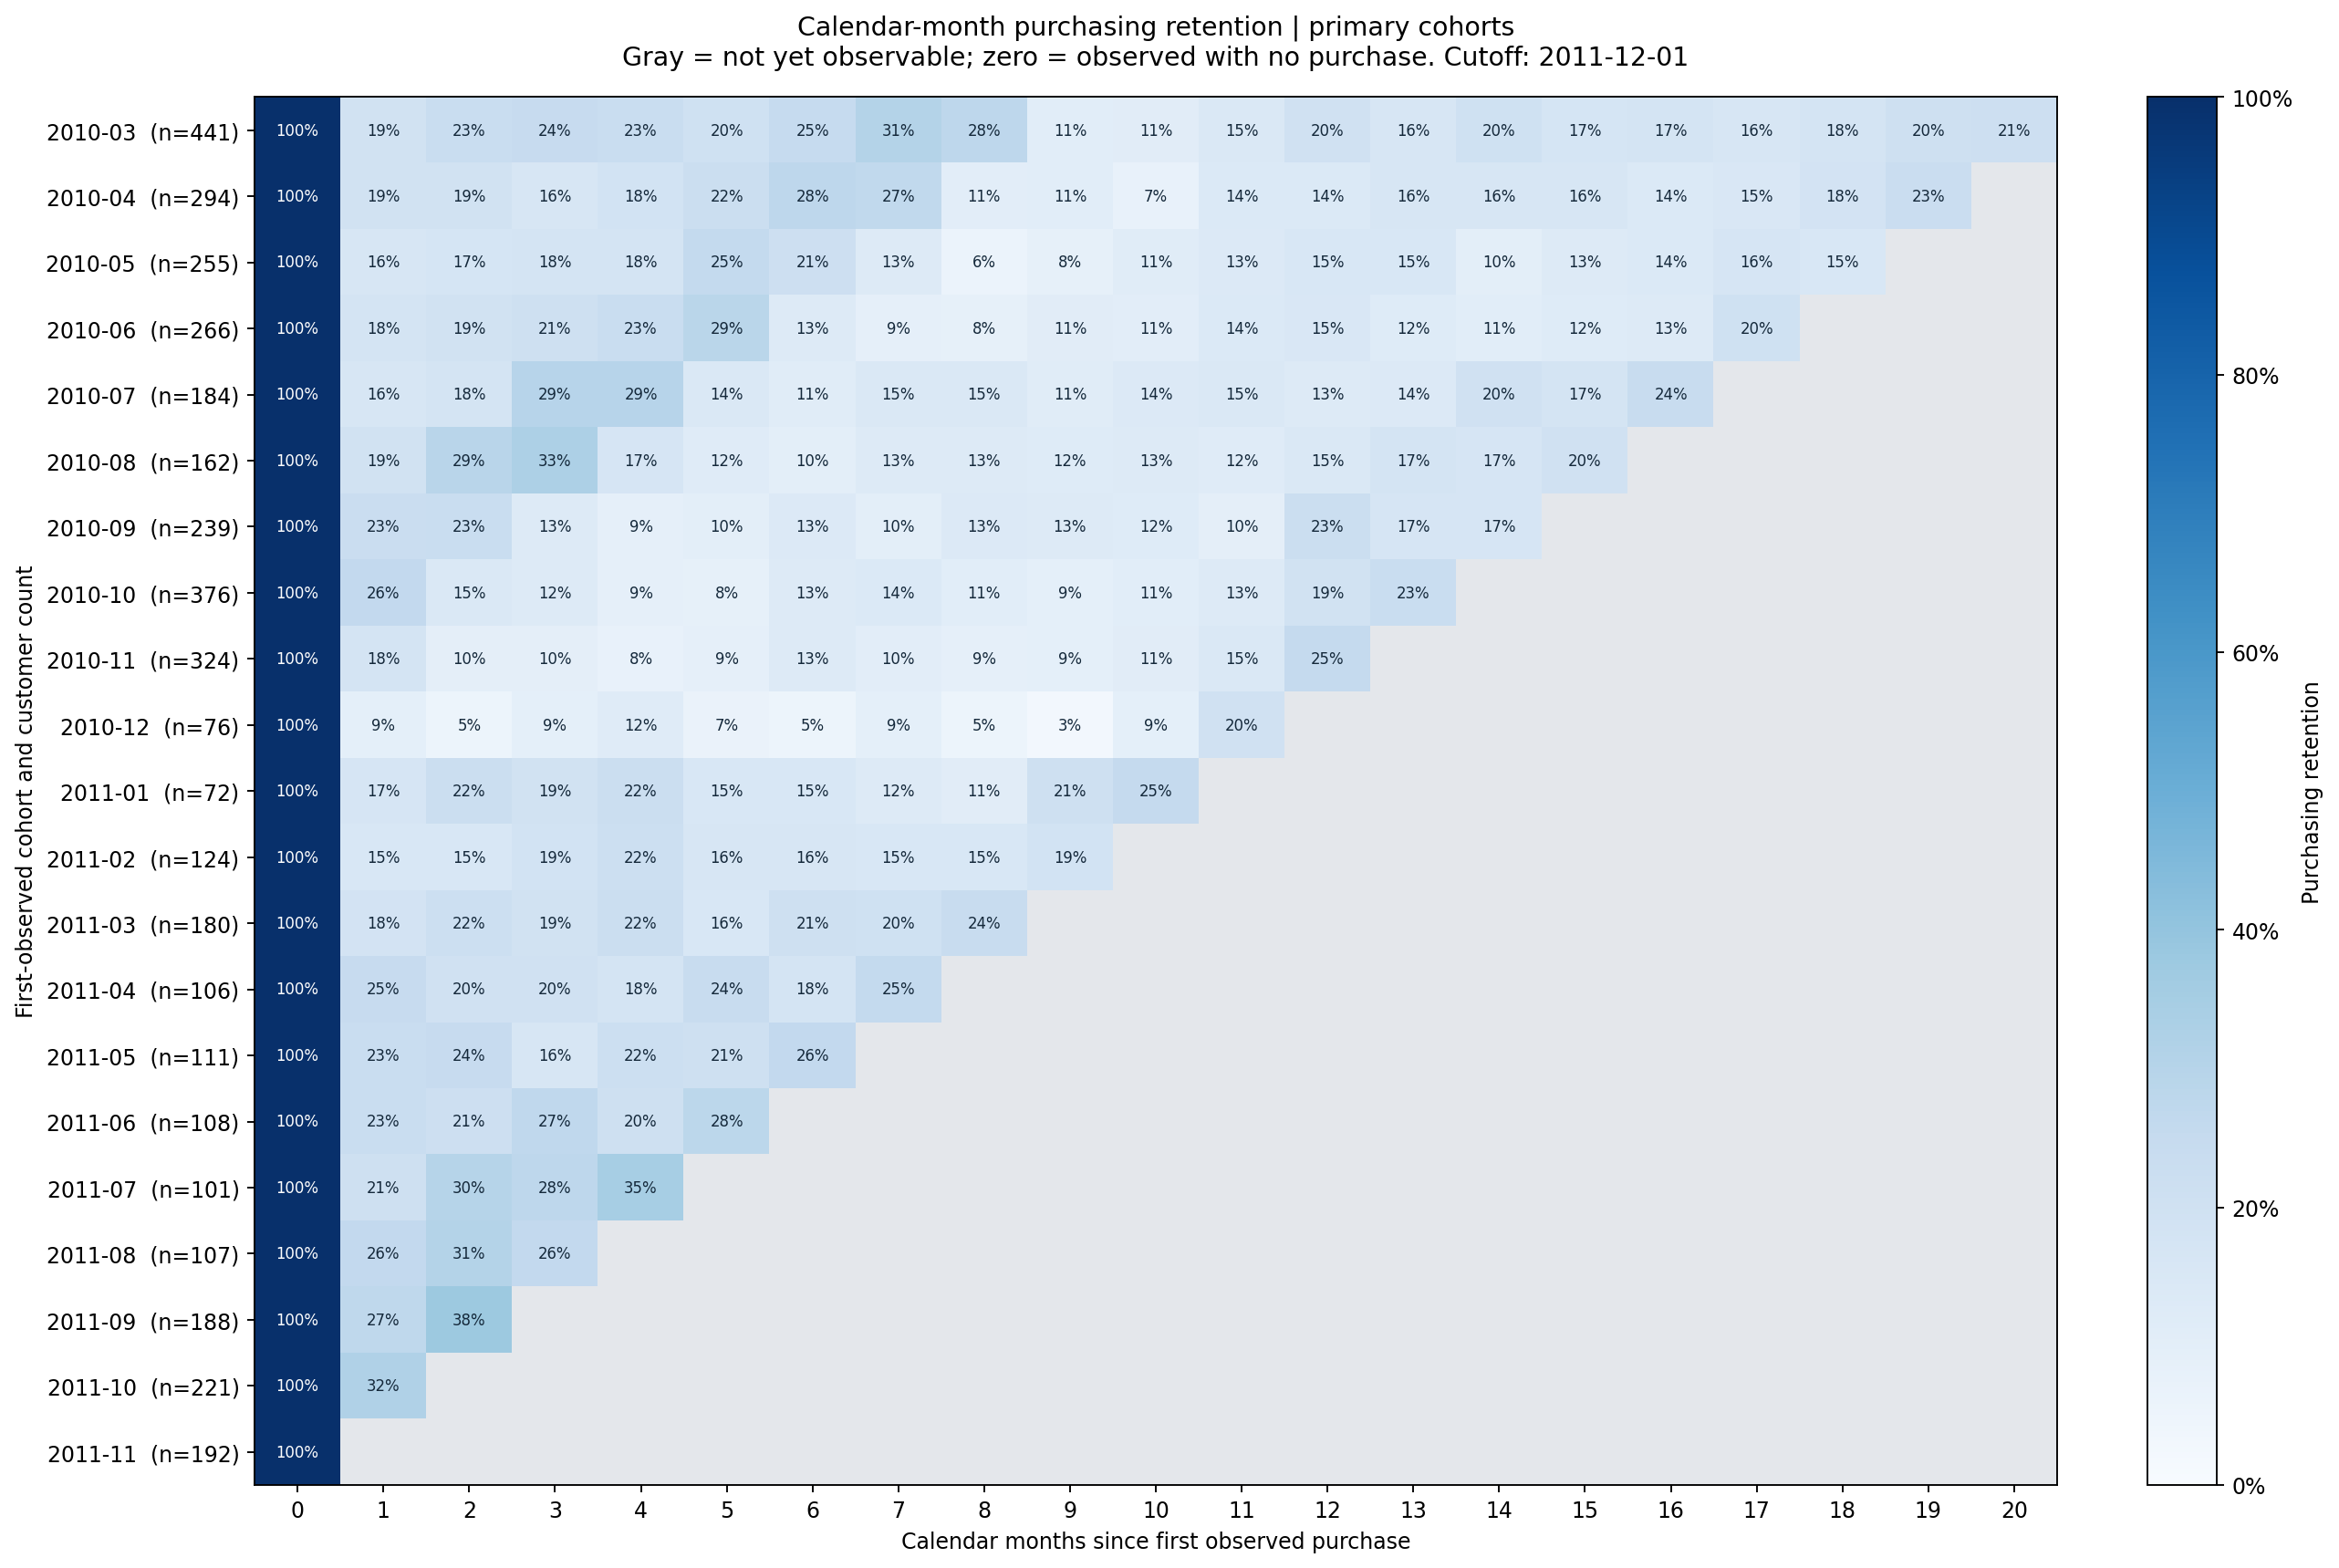

In [12]:
display(Image(filename=str(ROOT / "images/cohort_retention_heatmap.png")))

Every nonempty cohort starts at 100%. Unobserved cells stay gray; rows can rise after a skipped month. Labels show cohort sizes. Seasonal calendar exposure differs across cohorts, so visual differences are not causal effects.

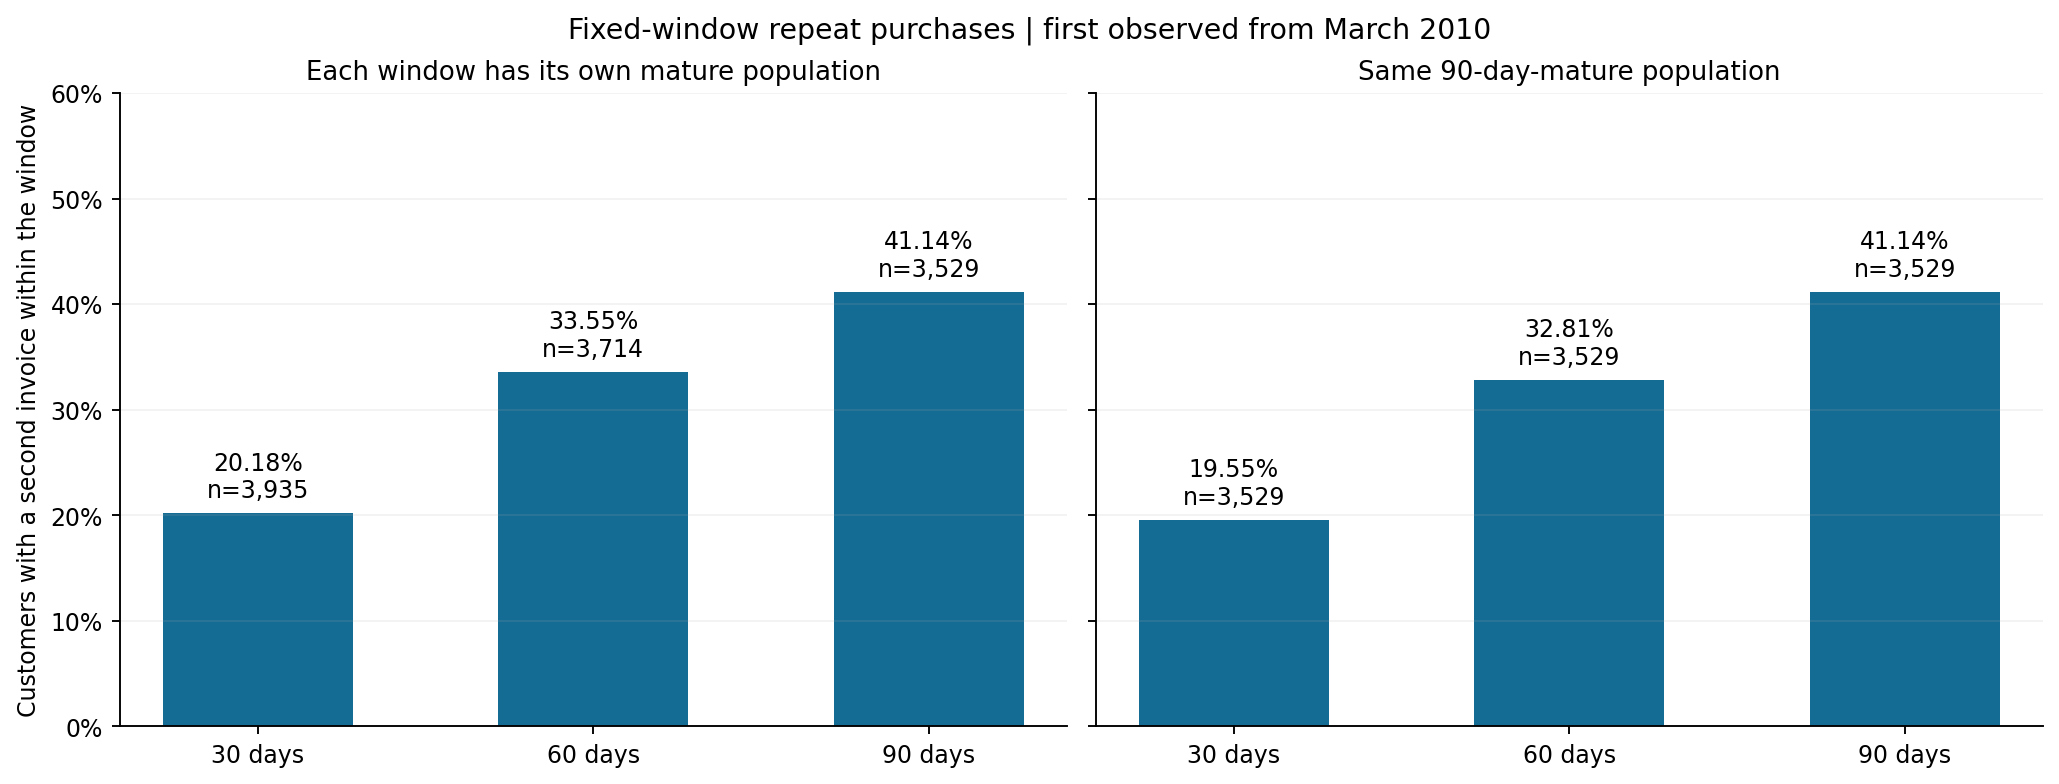

In [13]:
display(Image(filename=str(ROOT / "images/repeat_purchase_windows.png")))

The common-90-day panel uses the same 3,529 mature primary customers. Own-window denominators differ. Calendar-month retention is distinct from elapsed-day repeat purchasing. See `reports/cohort_visualization.md` and `reports/retention_analysis.md` for scope and limits.

<a id="customer-value"></a>

# 03 - RFM, Customer Value and Business Differences

Steps 11-12. Snapshot 2011-12-01; F/M use the trailing year and R uses full history. All historical customers, including dormant customers, remain in the analysis. Comparisons use full 90-day follow-up and first-order features.

In [14]:
from pathlib import Path
import json
import sys
import duckdb
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / "src/metric_spec.json").exists():
    ROOT = ROOT.parent
assert (ROOT / "src/metric_spec.json").exists()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
spec = json.loads((ROOT / "src/metric_spec.json").read_text(encoding="utf-8"))
params = {"history_start": spec["history_start_inclusive"], "cutoff": spec["analysis_cutoff_exclusive"], "cohort_start": spec["primary_cohort_start_inclusive"]}


In [15]:
from customer_analysis import validate_rfm
params["rfm_start"] = spec["rfm"]["measurement_start_inclusive"]
summary = json.loads((ROOT / "reports/customer_analysis_summary.json").read_text(encoding="utf-8"))
assert all(summary["validation"].values())
with duckdb.connect(str(ROOT / "data/processed/retention.duckdb"), read_only=True) as con:
    assert validate_rfm(con, params)
    assert validate_rfm(con, params, "sensitivity_orders_keep_duplicates", "rfm_keep_duplicates")
    display(con.execute("SELECT segment,count(*) customers,sum(monetary_12m_gbp) monetary_12m_gbp FROM rfm_snapshot GROUP BY segment ORDER BY customers DESC").df())
display(pd.DataFrame(summary["sensitivity"]))
display(pd.DataFrame(summary["reactivation"]))

,segment,customers,monetary_12m_gbp
0,Dormant beyond 12 months,1530,0.000
1,Loyal,1193,1434580.861
2,Champions,957,5488996.990
3,Inactive Single-Purchase,869,372912.870
4,At Risk Repeat,591,638470.821
5,Recent Occasional,521,217899.571
6,Promising New,160,51868.480


,scenario,customers,customers_removed,m_score_changes_common_customers,segment_changes_common_customers,monetary_12m_gbp,top_customer_count,identified_historical_sales_gbp,top_customer_sales_gbp,top_customer_sales_share
0,keep_within_sheet_duplicates,5821,0,36,4,8227435.493000,583,16573557.397000,10521045.198000,0.634809
1,exclude_invoice_541431,5821,0,3,1,8127545.993000,583,16441172.387000,10427610.898000,0.634238


,recency_threshold_days_exclusive,customers,historical_sales_gbp
0,60,2071,3754788.847000
1,90,1728,2917464.326000
2,120,1543,2455693.256000


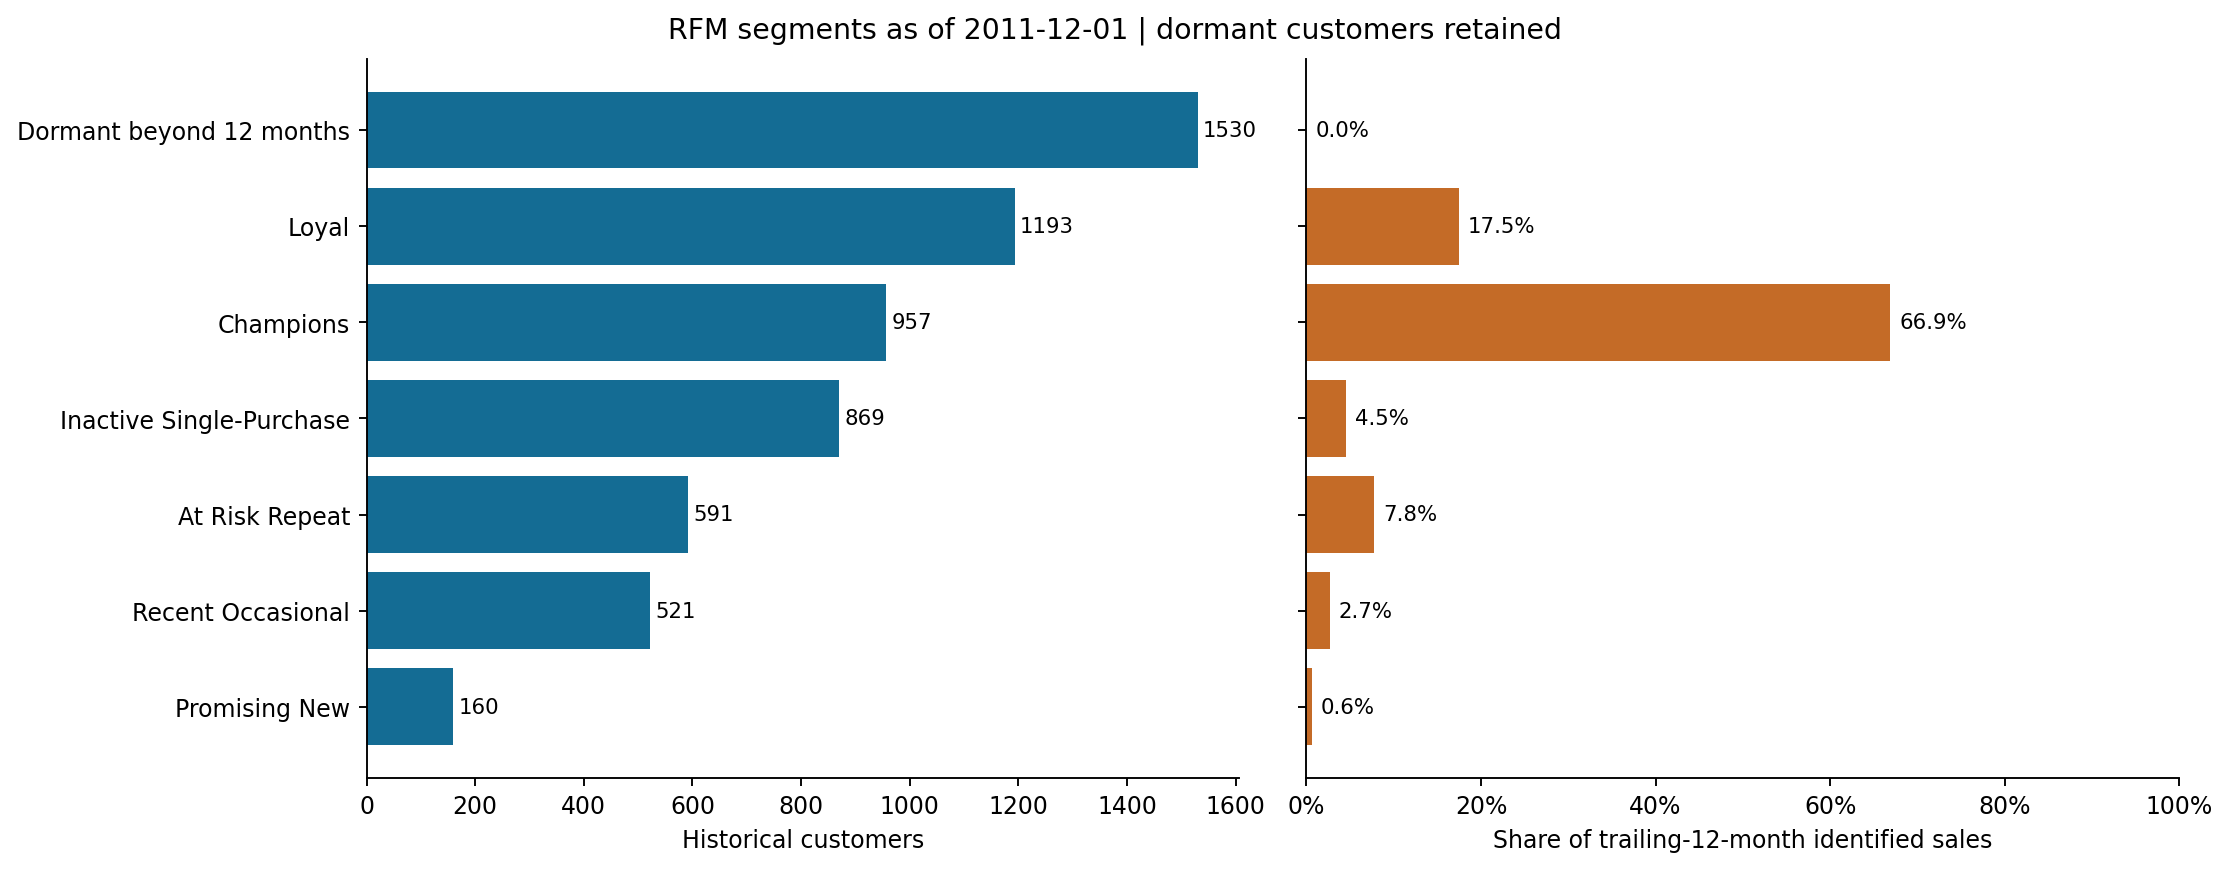

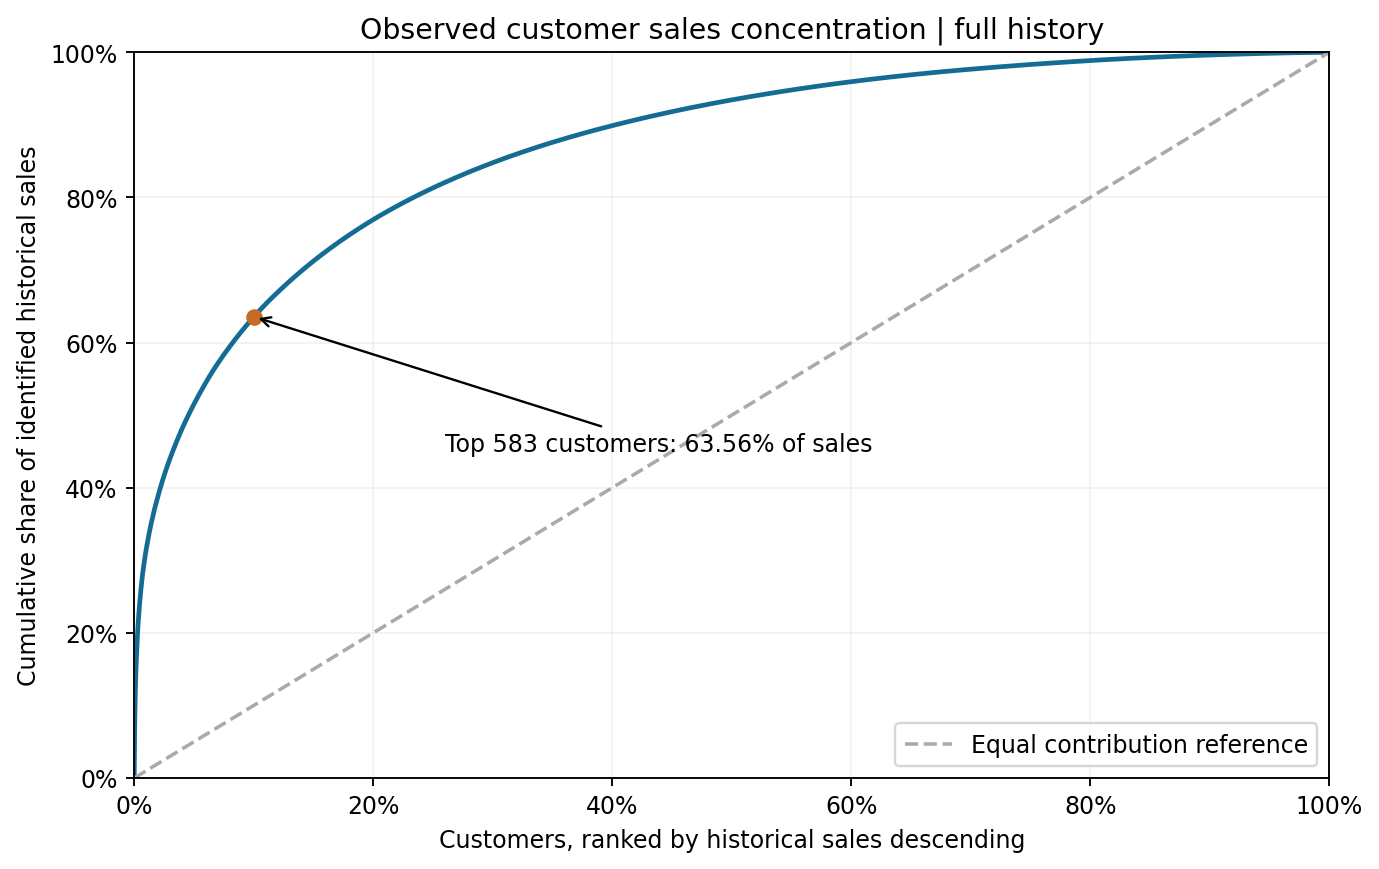

In [16]:
display(Image(filename=str(ROOT / "images/rfm_segments.png")))
display(Image(filename=str(ROOT / "images/customer_value_concentration.png")))

Historical concentration uses all identified historical sales. RFM monetary shares use trailing-year identified sales. Top 583 customers account for 63.56% of historical sales. Champions' monetary concentration partly follows from their definition. Neither measure predicts lifetime value or incremental campaign response.

,feature,group,eligible_customers,repeat_customers,publishable,repeat_rate_90d,wilson_low,wilson_high,mean_observed_sales_90d_gbp,median_observed_sales_90d_gbp
0,first_order_value_band,Under GBP 50,90,23,False,NaN,NaN,NaN,None,None
1,first_order_value_band,GBP 50-<100,205,65,True,0.317073,0.257237,0.383639,161.378683,88.700000
2,first_order_value_band,GBP 100-<250,1281,447,True,0.348946,0.323332,0.375464,304.776394,204.250000
3,first_order_value_band,GBP 250+,1953,917,True,0.469534,0.447482,0.491706,990.777671,610.450000
4,first_order_product_band,1 product,137,25,True,0.182482,0.126769,0.255516,607.990073,132.000000
5,first_order_product_band,2-5 products,342,124,True,0.362573,0.313410,0.414789,572.497018,175.675000
6,first_order_product_band,6+ products,3050,1303,True,0.427213,0.409760,0.444850,698.568224,404.375000
7,first_order_geography,United Kingdom,3185,1309,True,0.410989,0.394019,0.428173,652.068472,351.900000
8,first_order_geography,Other known country,340,142,True,0.417647,0.366432,0.470703,974.973356,580.675000
9,first_order_geography,Unknown,4,1,False,NaN,NaN,NaN,None,None


,feature,group,shared_months,shared_eligible_customers,standardized_rate,status
0,first_order_value_band,GBP 50-<100,3,64,NaN,Suppressed: a shared-cohort group has fewer th...
1,first_order_value_band,GBP 100-<250,3,397,NaN,Suppressed: a shared-cohort group has fewer th...
2,first_order_value_band,GBP 250+,3,659,NaN,Suppressed: a shared-cohort group has fewer th...
3,first_order_product_band,1 product,0,0,NaN,Unavailable: no shared months with minimum gro...
4,first_order_product_band,2-5 products,0,0,NaN,Unavailable: no shared months with minimum gro...
5,first_order_product_band,6+ products,0,0,NaN,Unavailable: no shared months with minimum gro...
6,first_order_geography,United Kingdom,8,1958,0.417723,Available: descriptive common-cohort standardi...
7,first_order_geography,Other known country,8,203,0.398223,Available: descriptive common-cohort standardi...


,first_order_value_band,first_order_product_band,eligible_customers,repeat_customers,repeat_rate_90d,wilson_low,wilson_high
0,Under GBP 50,1 product,39,7,NaN,NaN,NaN
1,Under GBP 50,2-5 products,40,9,NaN,NaN,NaN
2,Under GBP 50,6+ products,11,7,NaN,NaN,NaN
3,GBP 50-<100,1 product,32,5,NaN,NaN,NaN
4,GBP 50-<100,2-5 products,108,36,0.333333,0.251505,0.426611
5,GBP 50-<100,6+ products,65,24,NaN,NaN,NaN
6,GBP 100-<250,1 product,33,6,NaN,NaN,NaN
7,GBP 100-<250,2-5 products,110,39,0.354545,0.271441,0.447466
8,GBP 100-<250,6+ products,1138,402,0.353251,0.326017,0.381473
9,GBP 250+,1 product,33,7,NaN,NaN,NaN


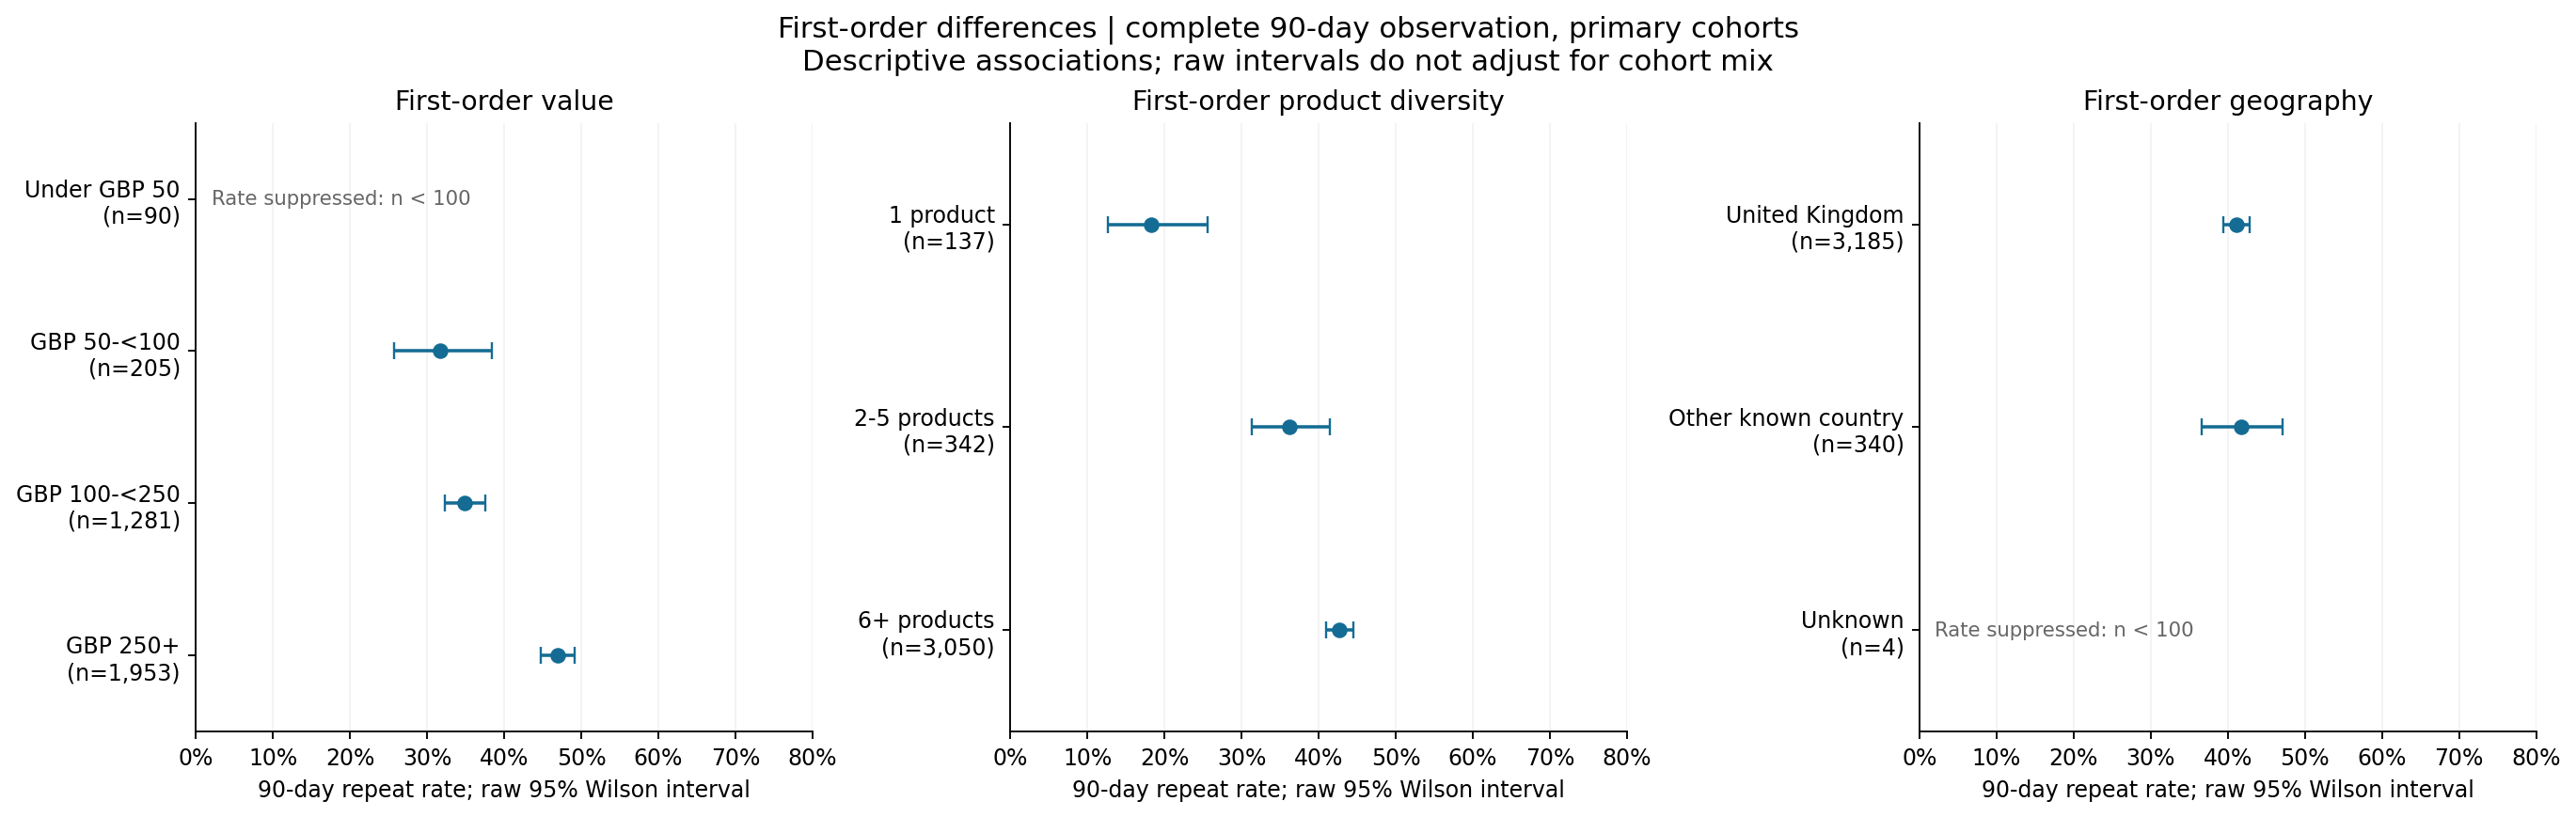

In [17]:
display(pd.DataFrame(summary["comparisons"]))
display(pd.DataFrame(summary["cohort_standardization"])[["feature","group","shared_months","shared_eligible_customers","standardized_rate","status"]])
display(pd.DataFrame(summary["basket_value_product_comparison"]))
display(Image(filename=str(ROOT / "images/customer_group_comparisons.png")))

First-order value and product diversity are associated with repeat purchasing, but these are observational differences. Geography is weak and changes ordering after common-cohort weighting. Small groups and unsupported adjusted comparisons are suppressed. Frozen first-order fields avoid attributing later behavior to baseline segments. See `reports/customer_value_and_segments.md` for complete evidence, limitations and testable business hypotheses. Steps 13-14 remain pending.